# Differential Expression and Pathway Follow-up
This notebook generates thesis-facing figures and tables for FOXA2 differential expression analyses in LIHC.

Storyline:
1. Pathway-level contrast (lead figure)
2. Gene-level volcano summaries
3. Expression distributions for selected representative genes
4. Method agreement and sensitivity summaries


In [1]:
from pathlib import Path

import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
})

ROOT = Path.cwd().resolve()
while ROOT != ROOT.parent and not (ROOT / 'outputs' / 'thesis').exists():
    ROOT = ROOT.parent

THESIS_ROOT = ROOT / 'outputs/thesis/04_differential_expression'
DATA_DIR = THESIS_ROOT / 'data'
SOURCE_DIR = DATA_DIR / 'source_inputs'
FIG_DIR = THESIS_ROOT / 'figures'
DATA_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

LABELS_PATH = SOURCE_DIR / 'sample_labels_used.csv'
COUNTS_PATH = ROOT / 'data/raw/rna/TCGA-LIHC.star_counts.tsv'

STEP2_PATH = SOURCE_DIR / 'fgsea_hallmark.csv'
STEP5_PATH = SOURCE_DIR / 'limma_voom_binary_results.csv'

ALPHA = 0.05

for p in [STEP2_PATH, STEP5_PATH, LABELS_PATH, COUNTS_PATH]:
    if not p.exists():
        raise FileNotFoundError(f'Missing required input: {p}')

fgsea = pd.read_csv(STEP2_PATH)
step5 = pd.read_csv(STEP5_PATH)
labels = pd.read_csv(LABELS_PATH)

print('Loaded rows:')
print('FGSEA Hallmark:', len(fgsea))
print('Samples with inferred labels:', len(labels))


Loaded rows:
FGSEA Hallmark: 50
Samples with inferred labels: 271


## 1) Pathway-Level Signal (FGSEA Hallmark, lead figure)


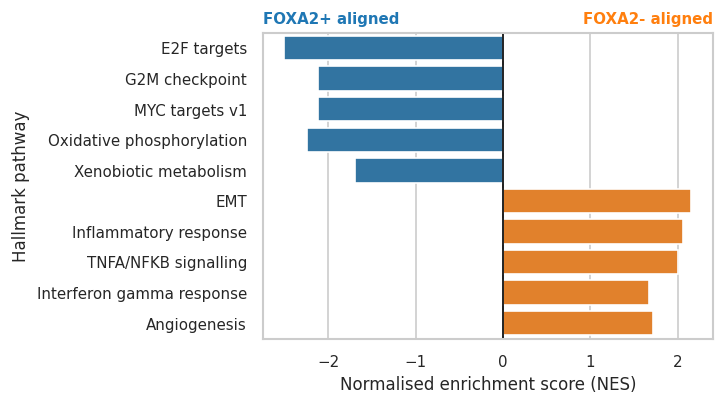

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/04_differential_expression/figures/01_pathway_nes_plot.png


In [2]:
fgsea = fgsea.copy()
fgsea['padj'] = pd.to_numeric(fgsea['padj'], errors='coerce')
fgsea['NES'] = pd.to_numeric(fgsea['NES'], errors='coerce')
fgsea['size'] = pd.to_numeric(fgsea['size'], errors='coerce')
fgsea['neg_log10_padj'] = -np.log10(fgsea['padj'])
fgsea['is_sig'] = fgsea['padj'] < ALPHA

label_map = {
    'HALLMARK_E2F_TARGETS': 'E2F targets',
    'HALLMARK_G2M_CHECKPOINT': 'G2M checkpoint',
    'HALLMARK_MYC_TARGETS_V1': 'MYC targets v1',
    'HALLMARK_OXIDATIVE_PHOSPHORYLATION': 'Oxidative phosphorylation',
    'HALLMARK_XENOBIOTIC_METABOLISM': 'Xenobiotic metabolism',
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION': 'EMT',
    'HALLMARK_INFLAMMATORY_RESPONSE': 'Inflammatory response',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB': 'TNFA/NFKB signalling',
    'HALLMARK_INTERFERON_GAMMA_RESPONSE': 'Interferon gamma response',
    'HALLMARK_ANGIOGENESIS': 'Angiogenesis',
}

foxa2_plus_pathways = [
    'HALLMARK_E2F_TARGETS',
    'HALLMARK_G2M_CHECKPOINT',
    'HALLMARK_MYC_TARGETS_V1',
    'HALLMARK_OXIDATIVE_PHOSPHORYLATION',
    'HALLMARK_XENOBIOTIC_METABOLISM',
]
foxa2_minus_pathways = [
    'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION',
    'HALLMARK_INFLAMMATORY_RESPONSE',
    'HALLMARK_TNFA_SIGNALING_VIA_NFKB',
    'HALLMARK_INTERFERON_GAMMA_RESPONSE',
    'HALLMARK_ANGIOGENESIS',
]
selected_order = foxa2_plus_pathways + foxa2_minus_pathways

plot_df = fgsea[fgsea['pathway'].isin(selected_order)].copy()
plot_df = plot_df.set_index('pathway').loc[selected_order].reset_index()
plot_df['pathway_label'] = plot_df['pathway'].map(label_map)
plot_df['direction'] = np.where(plot_df['NES'] > 0, 'FOXA2- aligned', 'FOXA2+ aligned')
plot_df.to_csv(DATA_DIR / 'fgsea_selected_pathways_for_lead_plot.csv', index=False)

fig, ax = plt.subplots(figsize=(6.2, 3.55))
sns.barplot(
    data=plot_df,
    y='pathway_label',
    x='NES',
    hue='direction',
    dodge=False,
    palette={'FOXA2+ aligned': '#1f77b4', 'FOXA2- aligned': '#ff7f0e'},
    ax=ax,
    errorbar=None,
)
ax.axvline(0.0, color='black', linewidth=1.0)
ax.set_xlabel('Normalised enrichment score (NES)')
ax.set_ylabel('Hallmark pathway')
ax.set_xlim(-2.75, 2.4)
ax.text(0.00, 1.02, 'FOXA2+ aligned', transform=ax.transAxes, ha='left', va='bottom', fontsize=9, fontweight='bold', color='#1f77b4')
ax.text(1.00, 1.02, 'FOXA2- aligned', transform=ax.transAxes, ha='right', va='bottom', fontsize=9, fontweight='bold', color='#ff7f0e')
if ax.legend_ is not None:
    ax.legend_.remove()
fig.tight_layout()
out = FIG_DIR / '01_pathway_nes_plot.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved:', out)


## 2) Volcano Plots for Primary Binary Models


'select()' returned 1:1 mapping between keys and columns


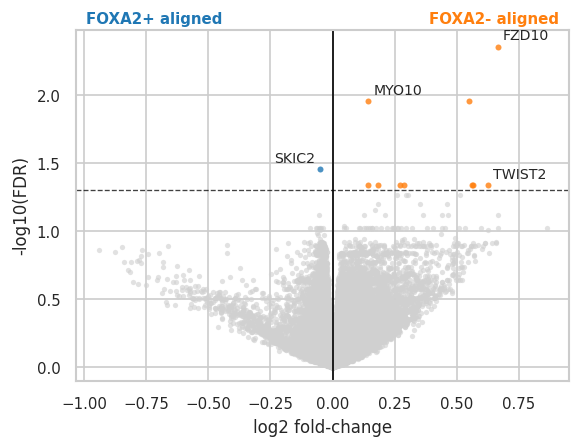

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/04_differential_expression/figures/02_volcano_limma_binary.png


In [3]:
import subprocess
import tempfile


def map_ensembl_to_symbol(ensembl_ids):
    ids = sorted({str(x).split('.')[0] for x in ensembl_ids if pd.notna(x) and str(x).strip()})
    if len(ids) == 0:
        return {}

    with tempfile.TemporaryDirectory() as td:
        ids_path = Path(td) / 'ids.txt'
        out_path = Path(td) / 'mapping.csv'
        ids_path.write_text('\n'.join(ids) + '\n')

        r_code = f"""
        suppressPackageStartupMessages({{
          library(data.table)
          library(AnnotationDbi)
          library(org.Hs.eg.db)
        }})
        ids <- readLines('{str(ids_path)}')
        m <- as.data.table(AnnotationDbi::select(
          org.Hs.eg.db,
          keys = ids,
          keytype = 'ENSEMBL',
          columns = c('ENSEMBL','SYMBOL')
        ))
        m <- m[!is.na(SYMBOL) & SYMBOL != '']
        m <- unique(m, by = c('ENSEMBL','SYMBOL'))
        fwrite(m, '{str(out_path)}')
        """

        subprocess.run(['Rscript', '-e', r_code], check=True)
        m = pd.read_csv(out_path)

    m = m.dropna(subset=['ENSEMBL', 'SYMBOL']).drop_duplicates(subset=['ENSEMBL'], keep='first')
    return dict(zip(m['ENSEMBL'].astype(str), m['SYMBOL'].astype(str)))


def make_volcano_limma_voom(df: pd.DataFrame) -> None:
    d = df.copy()
    d['logFC'] = pd.to_numeric(d['logFC'], errors='coerce')
    d['padj'] = pd.to_numeric(d['padj'], errors='coerce')
    d = d.dropna(subset=['logFC', 'padj']).copy()
    d = d[d['padj'] > 0].copy()
    d['neg_log10_fdr'] = -np.log10(d['padj'])
    d['is_sig'] = d['padj'] < ALPHA
    d['sig_direction'] = 'Not significant'
    d.loc[d['is_sig'] & (d['logFC'] < 0), 'sig_direction'] = 'Higher in FOXA2+'
    d.loc[d['is_sig'] & (d['logFC'] > 0), 'sig_direction'] = 'Higher in FOXA2-'
    d['gene_base'] = d['gene'].astype(str).str.split('.').str[0]

    label_ids = ['ENSG00000111432', 'ENSG00000145555', 'ENSG00000233608', 'ENSG00000204351']
    try:
        symbol_map = map_ensembl_to_symbol(set(d.loc[d['is_sig'], 'gene_base']).union(label_ids))
    except Exception:
        symbol_map = {}
    symbol_map.update({
        'ENSG00000111432': 'FZD10',
        'ENSG00000145555': 'MYO10',
        'ENSG00000233608': 'TWIST2',
        'ENSG00000204351': 'SKIC2',
    })
    d['gene_symbol'] = d['gene_base'].map(symbol_map)

    fig, ax = plt.subplots(figsize=(5.0, 3.9))
    non_sig = d[~d['is_sig']]
    sig_plus = d[d['sig_direction'] == 'Higher in FOXA2+']
    sig_minus = d[d['sig_direction'] == 'Higher in FOXA2-']
    ax.scatter(non_sig['logFC'], non_sig['neg_log10_fdr'], s=10, alpha=0.62, c='#D0D0D0', linewidths=0, zorder=1)
    ax.scatter(sig_plus['logFC'], sig_plus['neg_log10_fdr'], s=13, alpha=0.80, c='#1f77b4', linewidths=0, zorder=2)
    ax.scatter(sig_minus['logFC'], sig_minus['neg_log10_fdr'], s=13, alpha=0.80, c='#ff7f0e', linewidths=0, zorder=2)
    ax.axhline(-np.log10(ALPHA), linestyle='--', linewidth=0.8, color='black', alpha=0.75)
    ax.axvline(0.0, linewidth=1.0, color='black')
    ax.set_xlabel('log2 fold-change')
    ax.set_ylabel('-log10(FDR)')
    ax.set_xlim(-1.03, 0.95)
    ax.set_ylim(-0.10, 2.48)
    ax.text(0.02, 1.01, 'FOXA2+ aligned', transform=ax.transAxes, ha='left', va='bottom', fontsize=9, fontweight='bold', color='#1f77b4', clip_on=False)
    ax.text(0.98, 1.01, 'FOXA2- aligned', transform=ax.transAxes, ha='right', va='bottom', fontsize=9, fontweight='bold', color='#ff7f0e', clip_on=False)

    label_offsets = {
        'FZD10': (0.02, 0.03, 'left'),
        'MYO10': (0.02, 0.03, 'left'),
        'TWIST2': (0.02, 0.03, 'left'),
        'SKIC2': (-0.02, 0.03, 'right'),
    }
    for symbol, (dx, dy, ha) in label_offsets.items():
        rows = d[d['gene_symbol'] == symbol]
        if rows.empty:
            continue
        row = rows.sort_values('padj').iloc[0]
        ax.text(row['logFC'] + dx, row['neg_log10_fdr'] + dy, symbol, fontsize=8.5, ha=ha, va='bottom')

    fig.tight_layout()
    out_path = FIG_DIR / '02_volcano_limma_binary.png'
    fig.savefig(out_path, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close(fig)
    print('Saved:', out_path)


make_volcano_limma_voom(step5)


## 3) Representative Gene Expression Panel


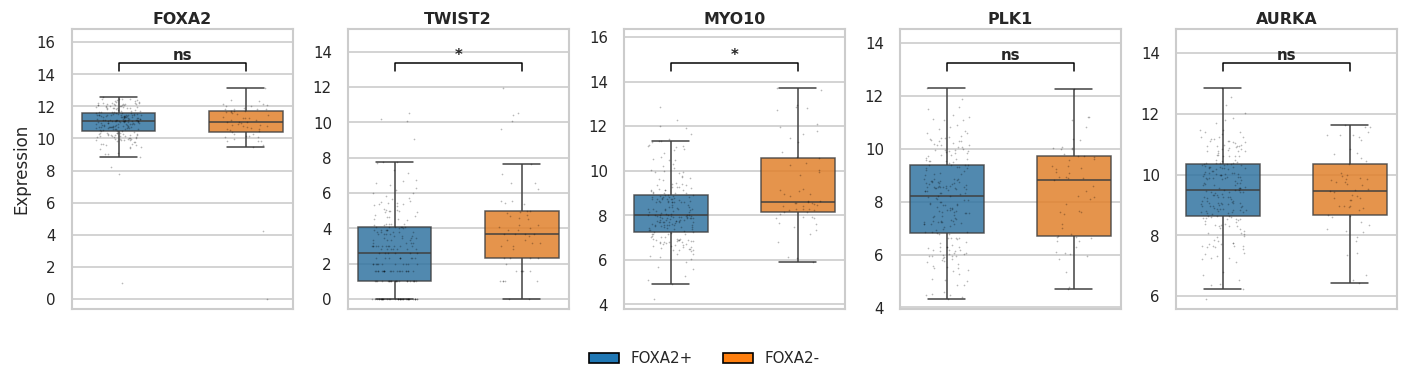

Saved: /home/lem/projects/mut-epi-origin/outputs/thesis/04_differential_expression/figures/03_representative_gene_expression_panel.png


,symbol,group_display,n_samples,median_expression,mean_expression,padj,is_significant
0,AURKA,FOXA2+,215,9.509775,9.476073,0.422690,False
1,AURKA,FOXA2-,57,9.475733,9.449608,0.422690,False
2,FOXA2,FOXA2+,215,11.100662,10.967630,0.435234,False
3,FOXA2,FOXA2-,57,11.028597,10.774100,0.435234,False
4,MYO10,FOXA2+,215,7.994353,8.212018,0.011055,True
5,MYO10,FOXA2-,57,8.592457,9.307744,0.011055,True
6,PLK1,FOXA2+,215,8.209453,8.073728,0.989586,False
7,PLK1,FOXA2-,57,8.826548,8.368340,0.989586,False
8,TWIST2,FOXA2+,215,2.584963,2.762042,0.045842,True
9,TWIST2,FOXA2-,57,3.700440,4.130923,0.045842,True


In [4]:
gene_panel = [
    {'symbol': 'FOXA2', 'ensembl_base': 'ENSG00000125798'},
    {'symbol': 'TWIST2', 'ensembl_base': 'ENSG00000233608'},
    {'symbol': 'MYO10', 'ensembl_base': 'ENSG00000145555'},
    {'symbol': 'PLK1', 'ensembl_base': 'ENSG00000166851'},
    {'symbol': 'AURKA', 'ensembl_base': 'ENSG00000087586'},
]
panel_df = pd.DataFrame(gene_panel)
counts = pd.read_csv(COUNTS_PATH, sep='\t')
counts['gene_base'] = counts['Ensembl_ID'].astype(str).str.split('.').str[0]
sample_cols = [c for c in counts.columns if c not in ['Ensembl_ID', 'gene_base']]
counts = counts.rename(columns={c: str(c)[:15] for c in sample_cols})
panel_counts = counts[counts['gene_base'].isin(set(panel_df['ensembl_base']))].copy()
if panel_counts.empty:
    raise ValueError('No panel genes were found in the counts matrix.')

labels_small = labels[['sample', 'group']].copy()
available_samples = [s for s in labels_small['sample'].astype(str).tolist() if s in panel_counts.columns]
if not available_samples:
    raise ValueError('No overlap between sample labels and counts columns for panel plotting.')
expr_long = panel_counts[['gene_base'] + available_samples].melt(id_vars='gene_base', var_name='sample', value_name='expression')
expr_long['expression'] = pd.to_numeric(expr_long['expression'], errors='coerce')
expr_long = expr_long.dropna(subset=['expression'])
expr_long = expr_long.merge(panel_df, left_on='gene_base', right_on='ensembl_base', how='left')
expr_long = expr_long.merge(labels_small, on='sample', how='inner')

group_order = ['foxa2_normal_pos', 'foxa2_abnormal_zero']
display_order = ['FOXA2+', 'FOXA2-']
display_labels = {'foxa2_normal_pos': 'FOXA2+', 'foxa2_abnormal_zero': 'FOXA2-'}
expr_long['group_display'] = expr_long['group'].map(display_labels)
expr_long['group'] = pd.Categorical(expr_long['group'], categories=group_order, ordered=True)
expr_long['group_display'] = pd.Categorical(expr_long['group_display'], categories=display_order, ordered=True)

step5_sig = step5.copy()
step5_sig['gene_base'] = step5_sig['gene'].astype(str).str.split('.').str[0]
step5_sig['padj'] = pd.to_numeric(step5_sig['padj'], errors='coerce')
step5_sig = step5_sig.dropna(subset=['padj']).sort_values('padj').drop_duplicates(subset=['gene_base'])
panel_df = panel_df.merge(step5_sig[['gene_base', 'padj']], left_on='ensembl_base', right_on='gene_base', how='left')
panel_df['is_significant'] = panel_df['padj'] < ALPHA

summary = (
    expr_long.groupby(['symbol', 'group_display'], observed=True, as_index=False)
    .agg(n_samples=('expression', 'size'), median_expression=('expression', 'median'), mean_expression=('expression', 'mean'))
)
summary = summary.merge(panel_df[['symbol', 'padj', 'is_significant']], on='symbol', how='left')
summary.to_csv(DATA_DIR / 'representative_gene_expression_summary.csv', index=False)

plot_order = [g['symbol'] for g in gene_panel]
palette = {'FOXA2+': '#1f77b4', 'FOXA2-': '#ff7f0e'}

def significance_stars(padj):
    if padj < 0.001:
        return '***'
    if padj < 0.01:
        return '**'
    if padj < 0.05:
        return '*'
    return 'ns'

def add_significance_bar(ax, values, label):
    y_min = float(values.min())
    y_max = float(values.max())
    y_range = y_max - y_min
    y = y_max + 0.08 * y_range
    h = 0.04 * y_range
    ax.plot([0, 0, 1, 1], [y, y + h, y + h, y], color='black', linewidth=0.9)
    ax.text(0.5, y + h, label, ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_ylim(y_min - 0.05 * y_range, y + h + 0.16 * y_range)

from matplotlib.patches import Patch
fig, axes = plt.subplots(1, 5, figsize=(11.9, 3.15), sharey=False)
for i, (ax, symbol) in enumerate(zip(axes, plot_order)):
    sub = expr_long[expr_long['symbol'] == symbol].copy()
    sig_row = panel_df[panel_df['symbol'] == symbol].iloc[0]
    star_label = significance_stars(float(sig_row['padj']))
    sns.boxplot(
        data=sub,
        x='group_display',
        y='expression',
        hue='group_display',
        order=display_order,
        hue_order=display_order,
        dodge=False,
        palette=palette,
        width=0.58,
        linewidth=0.9,
        fliersize=0,
        legend=False,
        ax=ax,
        boxprops={'alpha': 0.85},
    )
    sns.stripplot(data=sub, x='group_display', y='expression', order=display_order, color='black', alpha=0.28, size=1.0, jitter=0.18, ax=ax)
    add_significance_bar(ax, sub['expression'], star_label)
    ax.set_title(symbol, fontsize=9.5, fontweight='bold', pad=3)
    ax.set_xlabel('')
    ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0)
    ax.set_ylabel('Expression' if i == 0 else '')

legend_handles = [
    Patch(facecolor=palette['FOXA2+'], edgecolor='black', label='FOXA2+'),
    Patch(facecolor=palette['FOXA2-'], edgecolor='black', label='FOXA2-'),
]
fig.legend(handles=legend_handles, loc='lower center', bbox_to_anchor=(0.5, -0.03), ncol=2, frameon=False)
fig.tight_layout(rect=[0, 0.08, 1, 1], w_pad=1.0)
out = FIG_DIR / '03_representative_gene_expression_panel.png'
fig.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
plt.close(fig)
print('Saved:', out)
summary


## Figure Manifest


In [5]:
figs = [
    FIG_DIR / '01_pathway_nes_plot.png',
    FIG_DIR / '02_volcano_limma_binary.png',
    FIG_DIR / '03_representative_gene_expression_panel.png',
]
for f in figs:
    print(f.name, f.exists())


01_pathway_nes_plot.png True
02_volcano_limma_binary.png True
03_representative_gene_expression_panel.png True
